In [ ]:
print("dfk")

dfk


In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("work/pandas/sampledata1.csv")

In [ ]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
print(df.shape)

(9994, 21)


In [ ]:
df.dtypes

Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code        int64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

In [ ]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df["Order Date"] = pd.to_datetime(df["Order Date"], format="mixed")

In [ ]:
df["Ship Date"] = pd.to_datetime(df["Ship Date"], format="mixed")

In [ ]:
df["Order Month"] = df["Order Date"].dt.to_period("M").astype(str)

In [ ]:
df['Order Year'] = df["Order Date"].dt.year

In [ ]:
# Shipping Days
df["Shiping Days"] = (df["Ship Date"] - df["Order Date"]).dt.days

In [ ]:
# Profit Margin
df["Profit Margin"] = df["Profit"] / df["Sales"]

In [ ]:
df["Is Loss"] = df["Profit"] < 0

In [ ]:
total_sales = df["Sales"].sum()
total_sales

np.float64(2297200.8603)

In [ ]:
total_profit = df["Profit"].sum()
total_profit

np.float64(286397.0217)

In [ ]:
overall_margin = total_profit / total_sales
overall_margin

np.float64(0.12467217240315605)

In [ ]:
total_loss_count = df["Is Loss"].sum()
total_loss_count

np.int64(1871)

In [ ]:
loss_percentage = total_loss_count / len(df) * 100
loss_percentage

np.float64(18.721232739643785)

In [ ]:
print(f"Total Sales:        ${total_sales}")
print(f"Total Profit:       ${total_profit}")
print(f"Overall Margin:     {overall_margin}")
print(f"Loss-making orders: {total_loss_count} ({loss_percentage:.1f}% of all orders)")

Total Sales:        $2297200.8603
Total Profit:       $286397.0217
Overall Margin:     0.12467217240315605
Loss-making orders: 1871 (18.7% of all orders)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

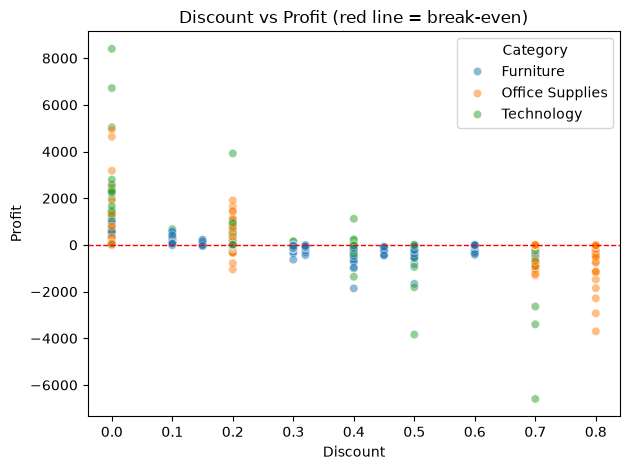

In [ ]:
plt.figure()
sns.scatterplot(x=df["Discount"], y=df["Profit"], hue="Category", alpha=0.5)
plt.axhline(0, color="red", linestyle="--", linewidth=1)
plt.title("Discount vs Profit (red line = break-even)")
plt.tight_layout()
plt.show()
plt.close()

In [ ]:
df.columns